# Random Forest
This notebook demonstrates building multiple Decision Trees on a custom dataset and visualizing them.

## 1.Imports and Dataset

In [ ]:
import math
from collections import Counter
import matplotlib.pyplot as plt

# Custom dataset
data = {
    1: {"age": "young",  "income": "high",   "student": "no",  "buys": "no"},
    2: {"age": "young",  "income": "high",   "student": "yes", "buys": "yes"},
    3: {"age": "middle", "income": "high",   "student": "no",  "buys": "yes"},
    4: {"age": "old",    "income": "medium", "student": "no",  "buys": "yes"},
    5: {"age": "old",    "income": "low",    "student": "yes", "buys": "yes"},
    6: {"age": "old",    "income": "low",    "student": "no",  "buys": "no"},
}

## 2.Entropy and Information Gain Functions

In [ ]:
def entropy(samples):
    labels = [data[i]["buys"] for i in samples]
    total = len(labels)
    count = Counter(labels)
    ent = 0
    for c in count:
        p = count[c] / total
        ent -= p * math.log2(p)
    return ent

def information_gain(samples, feature):
    total_entropy = entropy(samples)
    total = len(samples)
    subsets = {}
    for i in samples:
        val = data[i][feature]
        subsets.setdefault(val, []).append(i)
    weighted_entropy = 0
    for val in subsets:
        sub_entropy = entropy(subsets[val])
        weight = len(subsets[val]) / total
        weighted_entropy += weight * sub_entropy
    info_gain = total_entropy - weighted_entropy
    return info_gain

## 3.Build Decision Tree

In [ ]:
def build_tree(samples, features, depth=0):
    labels = [data[i]["buys"] for i in samples]
    count = Counter(labels)
    if len(count) == 1:
        return labels[0]
    if count.get("yes", 0) == count.get("no", 0):
        return "mixed"
    if not features:
        majority = count.most_common(1)[0][0]
        return majority  
    gains = {f: information_gain(samples, f) for f in features}
    best_feature = max(gains, key=gains.get)
    tree = {best_feature: {}}
    subsets = {}
    for i in samples:
        val = data[i][best_feature]
        subsets.setdefault(val, []).append(i)
    remaining_features = [f for f in features if f != best_feature]
    for val in subsets:
        subtree = build_tree(subsets[val], remaining_features, depth+1)
        tree[best_feature][val] = subtree
    return tree

# Create multiple trees
tree1 = build_tree([1,2,2,4,6], ["age","student"])
tree2 = build_tree([1,3,4,5,5], ["income","student"])
tree3 = build_tree([2,3,4,6,6], ["age","income"])

## 4.Visulaize Decision Trees

<Figure size 640x480 with 0 Axes>

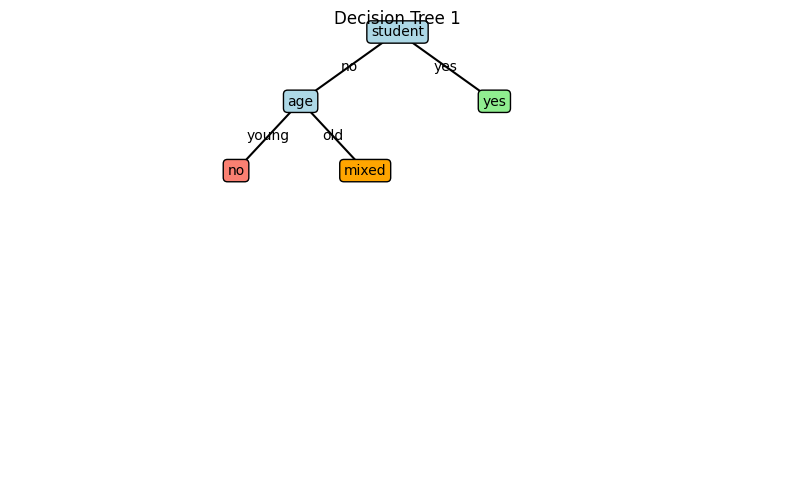

<Figure size 640x480 with 0 Axes>

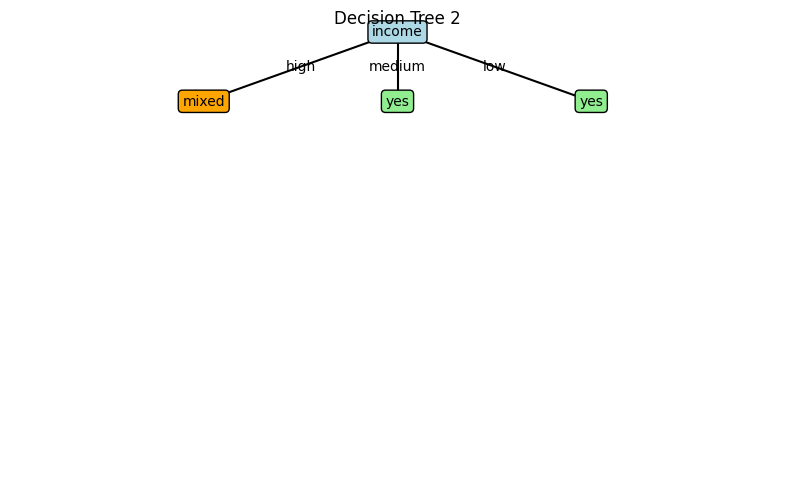

<Figure size 640x480 with 0 Axes>

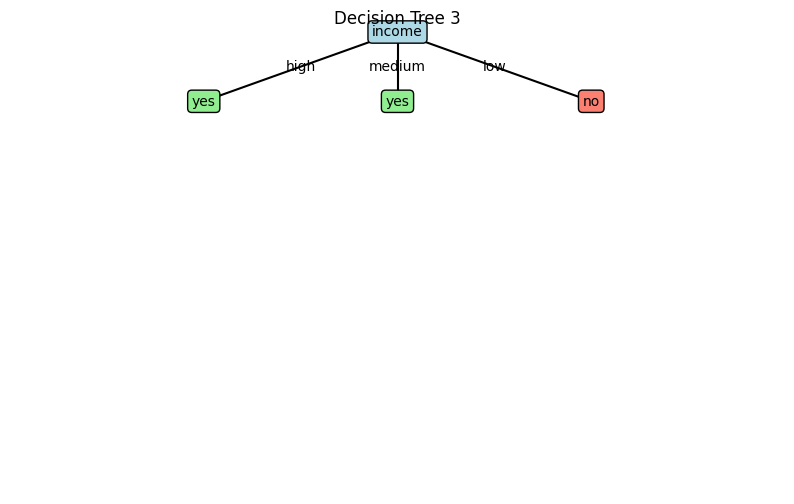

In [ ]:
def draw_tree(tree, x=0.5, y=1.0, dx=0.25, dy=0.15, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,6))
        ax.set_xlim(0,1) 
        ax.set_ylim(0,1)
        ax.axis('off')
    if isinstance(tree, dict):
        feature = list(tree.keys())[0]
        ax.text(x, y, feature, ha='center', va='center', bbox=dict(boxstyle="round", fc="lightblue"))
        children = tree[feature]
        n = len(children)
        start_x = x - dx*(n-1)/2
        for i, (val, subtree) in enumerate(children.items()):
            child_x = start_x + i*dx
            child_y = y - dy  
            ax.plot([x, child_x], [y, child_y], 'k-')
            ax.text((x+child_x)/2, (y+child_y)/2, val, ha='center', va='center')
            draw_tree(subtree, child_x, child_y, dx/1.5, dy, ax)
    else:
        color = "lightgreen" if tree=="yes" else "salmon" if tree=="no" else "orange"
        ax.text(x, y, tree, ha='center', va='center', bbox=dict(boxstyle="round", fc=color))
    return ax

plt.figure()
draw_tree(tree1)
plt.title("Decision Tree 1")
plt.show()
plt.figure()
draw_tree(tree2)
plt.title("Decision Tree 2")
plt.show()
plt.figure()
draw_tree(tree3)
plt.title("Decision Tree 3")
plt.show()